# Customer Churn Analysis — Telco Dataset
**Tools:** Python, Pandas, Seaborn, Matplotlib, Scikit-learn

## Objective
Analyze customer churn patterns for a telecom company with 7,043 customers 
and identify actionable recommendations to reduce the 26.54% churn rate.



In [86]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Import Libraries

In [87]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report


## 2. Load Data

In [88]:
# Load the dataset
df = pd.read_csv(
    r'C:\Users\Vaish\OneDrive\Desktop\DA_projects\customer-churn-analysis-main\data\Telco_customer_churn.csv'
)

# Check shape
print("Shape:", df.shape)

# Preview data
df.head()

Shape: (7043, 33)


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [89]:
# Check data types of every column
print(df.dtypes)
print("---")
# Check basic statistics
print(df.describe())

CustomerID               str
Count                  int64
Country                  str
State                    str
City                     str
Zip Code               int64
Lat Long                 str
Latitude             float64
Longitude            float64
Gender                   str
Senior Citizen           str
Partner                  str
Dependents               str
Tenure Months          int64
Phone Service            str
Multiple Lines           str
Internet Service         str
Online Security          str
Online Backup            str
Device Protection        str
Tech Support             str
Streaming TV             str
Streaming Movies         str
Contract                 str
Paperless Billing        str
Payment Method           str
Monthly Charges      float64
Total Charges            str
Churn Label              str
Churn Value            int64
Churn Score            int64
CLTV                   int64
Churn Reason             str
dtype: object
---
        Count      Zip Co

## 3. Data Cleaning

In [90]:
# Fix Total Charges
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
df['Total Charges'] = df['Total Charges'].fillna(df['Total Charges'].median())

# Drop useless columns
df.drop(['CustomerID', 'Count', 'Country', 'State', 'Lat Long'], axis=1, inplace=True)

# Create binary churn column
df['Churn_Binary'] = (df['Churn Label'] == 'Yes').astype(int)

# Rename columns to remove spaces
df.columns = df.columns.str.replace(' ', '_')

# Confirm
print("Total Charges nulls:", df['Total_Charges'].isnull().sum())
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Total Charges nulls: 0
Shape: (7043, 29)
Columns: ['City', 'Zip_Code', 'Latitude', 'Longitude', 'Gender', 'Senior_Citizen', 'Partner', 'Dependents', 'Tenure_Months', 'Phone_Service', 'Multiple_Lines', 'Internet_Service', 'Online_Security', 'Online_Backup', 'Device_Protection', 'Tech_Support', 'Streaming_TV', 'Streaming_Movies', 'Contract', 'Paperless_Billing', 'Payment_Method', 'Monthly_Charges', 'Total_Charges', 'Churn_Label', 'Churn_Value', 'Churn_Score', 'CLTV', 'Churn_Reason', 'Churn_Binary']


In [91]:
# Save cleaned version to data folder
df.to_csv(
    r'C:\Users\Vaish\OneDrive\Desktop\DA_projects\customer-churn-analysis-main\data\telco_churn_cleaned.csv',
    index=False
)

print("Cleaned data saved successfully!")
print("Shape:", df.shape)

Cleaned data saved successfully!
Shape: (7043, 29)


## 4. Exploratory Data Analysis

C:\Users\Vaish\AppData\Local\Temp\ipykernel_26928\3001250169.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Churn_Label', data=df, palette= {'No': 'steelblue', 'Yes': 'tomato'})


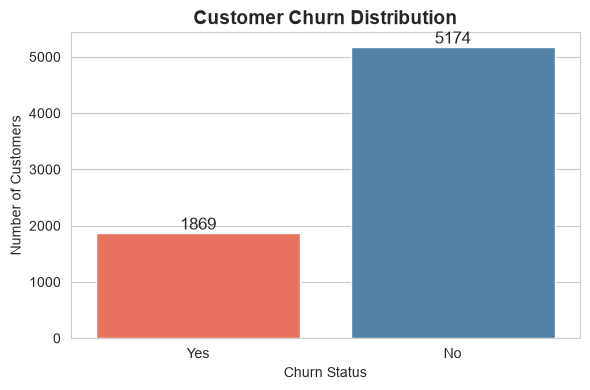

✅ Plot saved!


In [92]:
# Set the visual style for all plots
sns.set_style("whitegrid")
plt.figure(figsize=(6, 4))

ax = sns.countplot(x='Churn_Label', data=df, palette= {'No': 'steelblue', 'Yes': 'tomato'})

# Add count labels on top of each bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12)

plt.title('Customer Churn Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Churn Status')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.savefig(
    r'C:\Users\Vaish\OneDrive\Desktop\DA_projects\customer-churn-analysis-main\visuals\churn_distribution.png',
    dpi=150
)
plt.show()

print("✅ Plot saved!")

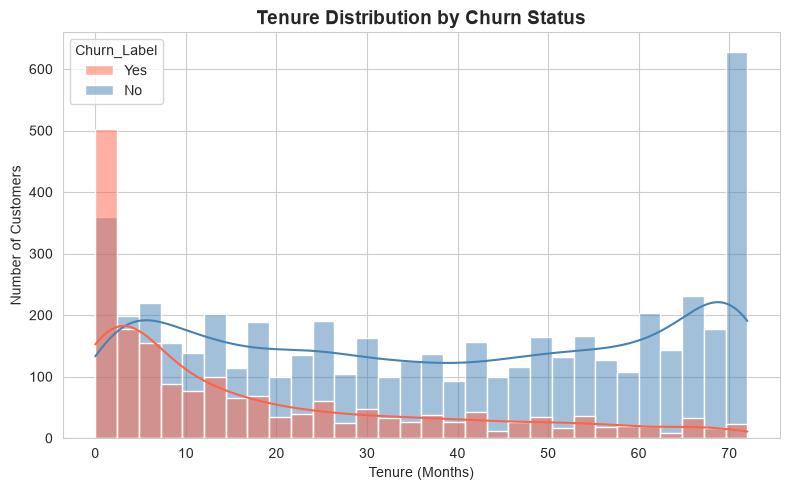

✅ Plot saved!


In [93]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x='Tenure_Months', hue='Churn_Label',
             bins=30, kde=True, palette={'No': 'steelblue', 'Yes': 'tomato'})

plt.title('Tenure Distribution by Churn Status', fontsize=14, fontweight='bold')
plt.xlabel('Tenure (Months)')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.savefig(
    r'C:\Users\Vaish\OneDrive\Desktop\DA_projects\customer-churn-analysis-main\visuals\tenure_churn.png',
    dpi=150
)
plt.show()

print("✅ Plot saved!")

C:\Users\Vaish\AppData\Local\Temp\ipykernel_26928\1729823290.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn_Label', y='Monthly_Charges', data=df,


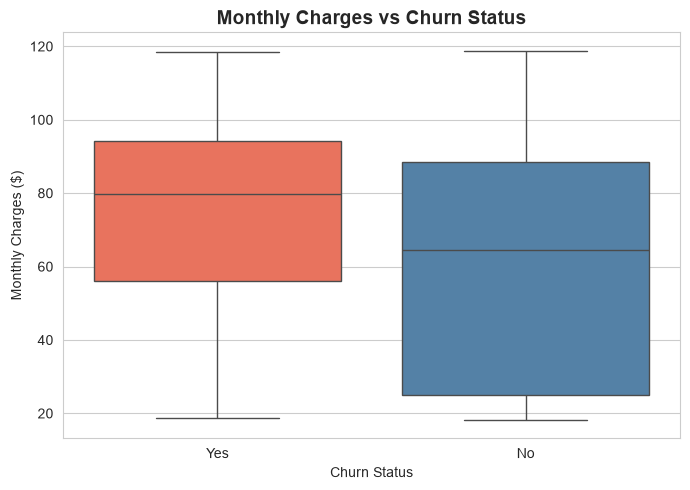

✅ Plot saved!


In [94]:
plt.figure(figsize=(7, 5))

sns.boxplot(x='Churn_Label', y='Monthly_Charges', data=df,
            palette={'No': 'steelblue', 'Yes': 'tomato'})

plt.title('Monthly Charges vs Churn Status', fontsize=14, fontweight='bold')
plt.xlabel('Churn Status')
plt.ylabel('Monthly Charges ($)')
plt.tight_layout()
plt.savefig(
    r'C:\Users\Vaish\OneDrive\Desktop\DA_projects\customer-churn-analysis-main\visuals\charges_churn.png',
    dpi=150
)
plt.show()

print("✅ Plot saved!")

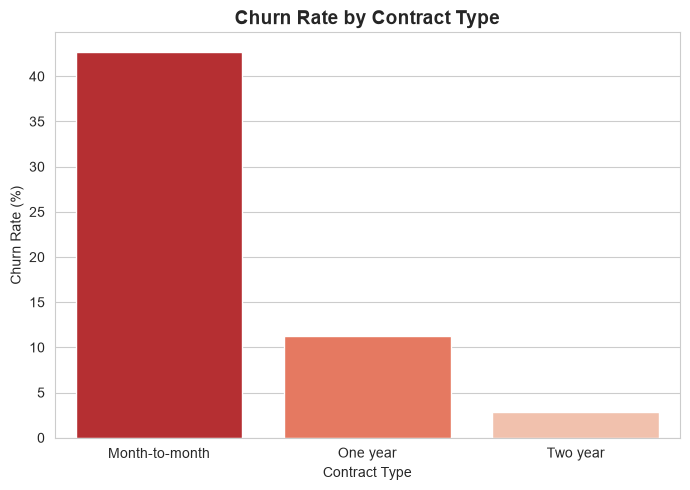

✅ Plot saved!


In [95]:
plt.figure(figsize=(7, 5))

contract_churn = df.groupby('Contract')['Churn_Binary'].mean().reset_index()
contract_churn['Churn_Rate'] = (contract_churn['Churn_Binary'] * 100).round(2)
contract_churn = contract_churn.sort_values('Churn_Rate', ascending=False)

sns.barplot(x='Contract', y='Churn_Rate', data=contract_churn, hue='Contract', palette='Reds_r', legend=False)

plt.title('Churn Rate by Contract Type', fontsize=14, fontweight='bold')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')
plt.tight_layout()
plt.savefig(
    r'C:\Users\Vaish\OneDrive\Desktop\DA_projects\customer-churn-analysis-main\visuals\contract_churn.png',
    dpi=150
)
plt.show()

print("✅ Plot saved!")

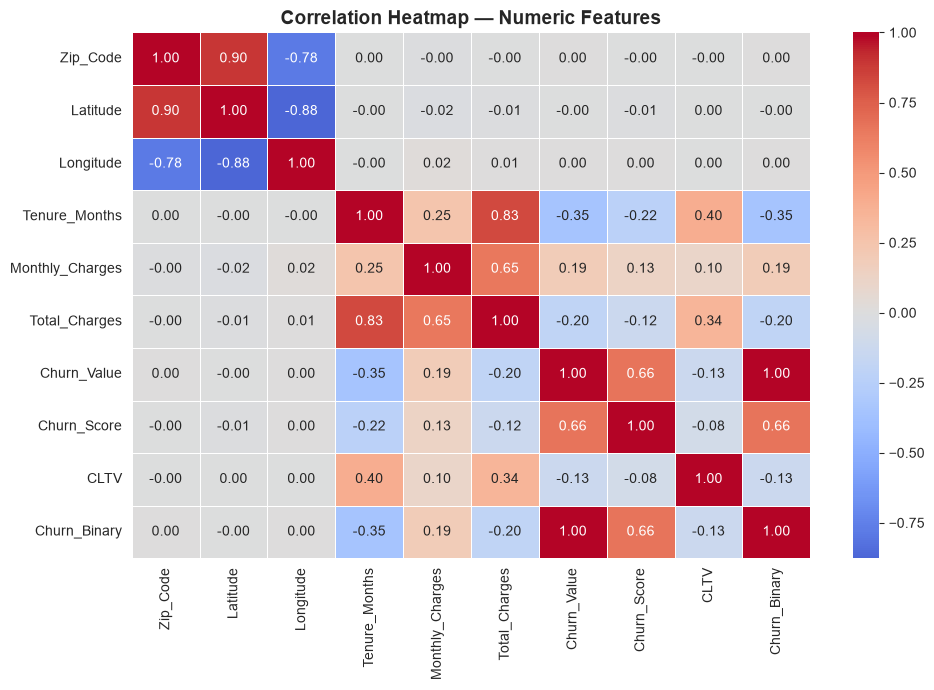

✅ Plot saved!


In [96]:
plt.figure(figsize=(10, 7))

numeric_df = df.select_dtypes(include='number')

sns.heatmap(numeric_df.corr(), 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm',
            center=0,
            linewidths=0.5)

plt.title('Correlation Heatmap — Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(
    r'C:\Users\Vaish\OneDrive\Desktop\DA_projects\customer-churn-analysis-main\visuals\correlation_heatmap.png',
    dpi=150
)
plt.show()

print("✅ Plot saved!")

## 5. Logistic Regression Model

In [97]:
from sklearn.preprocessing import LabelEncoder

# Select features for the model
features = ['Tenure_Months', 'Monthly_Charges', 'Total_Charges', 
            'Churn_Score', 'CLTV']

X = df[features]
y = df['Churn_Binary']

# Split data — 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the model
model = LogisticRegression(max_iter=500)
model.fit(X_train_scaled, y_train)

# Evaluate the model
y_pred = model.predict(X_test_scaled)
print(classification_report(y_test, y_pred))

# Feature importance
importance = pd.DataFrame({
    'Feature': features, 
    'Coefficient': model.coef_[0]
})
print(importance.sort_values('Coefficient', ascending=False))

              precision    recall  f1-score   support

           0       0.92      0.93      0.92      1009
           1       0.81      0.79      0.80       400

    accuracy                           0.89      1409
   macro avg       0.86      0.86      0.86      1409
weighted avg       0.89      0.89      0.89      1409

           Feature  Coefficient
3      Churn_Score     4.239472
1  Monthly_Charges     1.015635
4             CLTV     0.015456
2    Total_Charges    -0.015303
0    Tenure_Months    -1.429389
